Celda 1: Importación de Librerías y Configuración de Semillas

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Configurar semillas para asegurar la reproducibilidad estricta
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Entorno y librerías inicializadas correctamente.")
print(f"Versión de TensorFlow: {tf.__version__}")

✅ Entorno y librerías inicializadas correctamente.
Versión de TensorFlow: 2.21.0


Celda 2: Carga de Datos y Análisis Exploratorio Rápido (EDA)

In [2]:
# Rutas locales relativas a la carpeta /final_project
TRAIN_PATH = "data/train.csv"
TEST_PATH = "data/test.csv"

# Cargar los conjuntos de datos
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Dimensiones de Train: {train_df.shape}")
print(f"Dimensiones de Test: {test_df.shape}")

# Visualizar valores nulos y distribución del target
print("\nDistribución del Target (Transported):")
print(train_df['Transported'].value_counts(normalize=True))

# Mostrar primeras filas
train_df.head()

Dimensiones de Train: (8693, 14)
Dimensiones de Test: (4277, 13)

Distribución del Target (Transported):
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


Celda 3: Feature Engineering

In [3]:
def preprocess_features(df):
    # Clonar para evitar modificar el dataframe original
    df_copy = df.copy()
    
    # 1. Extraer grupo y número de pasajero desde PassengerId
    df_copy[['PassengerGroup', 'PassengerNum']] = df_copy['PassengerId'].str.split('_', expand=True)
    df_copy['PassengerGroup'] = df_copy['PassengerGroup'].astype(int)
    
    # Calcular tamaño del grupo familiar/viaje
    group_sizes = df_copy['PassengerGroup'].value_counts()
    df_copy['GroupSize'] = df_copy['PassengerGroup'].map(group_sizes)
    
    # 2. Desglosar la cabina (Cabin) en Deck, Num, Side
    # El formato es Deck/Num/Side (ej. B/0/P)
    df_copy['Cabin'].fillna('Missing/Missing/Missing', inplace=True)
    cabin_split = df_copy['Cabin'].str.split('/', expand=True)
    df_copy['Cabin_Deck'] = cabin_split[0]
    df_copy['Cabin_Side'] = cabin_split[2] # P (Port) o S (Starboard)
    
    # 3. Sumarizar gastos en lujos
    luxury_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in luxury_cols:
        df_copy[col] = df_copy[col].fillna(0)
    df_copy['TotalSpend'] = df_copy[luxury_cols].sum(axis=1)
    df_copy['HasSpent'] = (df_copy['TotalSpend'] > 0).astype(int)
    
    # Eliminar columnas de alta cardinalidad o no utilizables directamente
    cols_to_drop = ['PassengerId', 'Cabin', 'Name', 'PassengerNum']
    df_copy.drop(columns=[c for c in cols_to_drop if c in df_copy.columns], inplace=True)
    
    return df_copy

# Procesar ambos conjuntos
train_processed = preprocess_features(train_df)
test_processed = preprocess_features(test_df)

# Separar características y variable objetivo
X = train_processed.drop(columns=['Transported'])
y = train_processed['Transported'].astype(int) # True/False a 1/0

X_test = test_processed.copy()

print("✅ Ingeniería de características completada.")
print(f"Columnas resultantes: {list(X.columns)}")

✅ Ingeniería de características completada.
Columnas resultantes: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'PassengerGroup', 'GroupSize', 'Cabin_Deck', 'Cabin_Side', 'TotalSpend', 'HasSpent']


C:\Users\fundacion\AppData\Local\Temp\ipykernel_17680\3124522726.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Cabin'].fillna('Missing/Missing/Missing', inplace=True)
C:\Users\fundacion\AppData\Local\Temp\ipykernel_17680\3124522726.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

Celda 4: Pipeline de Preprocesamiento y Separación de Datos (Evitando Data Leakage)

In [4]:
# Definir columnas por tipo de datos
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'GroupSize']
categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side', 'HasSpent']

# Pipeline para variables numéricas (Imputación por mediana + Escalado estándar)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas (Imputación por el valor más frecuente + One-Hot Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Unificar preprocesador usando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# División de entrenamiento y validación interna (Holdout 80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# Ajustar preprocesador SOLO con los datos de entrenamiento para evitar fuga de información (Data Leakage)
X_train_pre = preprocessor.fit_transform(X_train)
X_val_pre = preprocessor.transform(X_val)
X_test_pre = preprocessor.transform(X_test)

print(f"Dimensiones de X_train_pre: {X_train_pre.shape}")
print(f"Dimensiones de X_val_pre: {X_val_pre.shape}")

Dimensiones de X_train_pre: (6954, 32)
Dimensiones de X_val_pre: (1739, 32)


Celda 5: Definición de la Arquitectura de la Red Neuronal (ResNet Tabular)

In [5]:
def build_resnet_tabular(input_dim):
    inputs = layers.Input(shape=(input_dim,))
    
    # Capa de entrada densa inicial
    x = layers.Dense(128, activation='swish')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Primer bloque residual (Skip Connection)
    residual_1 = x
    x = layers.Dense(128, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, residual_1]) # Conexión de atajo
    
    # Segundo bloque residual
    residual_2 = x
    x = layers.Dense(128, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, residual_2])
    
    # Capa densa intermedia de reducción
    x = layers.Dense(64, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    # Capa de salida (Clasificación Binaria)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs, name="ResNet_Tabular_Spaceship")
    return model

input_shape = X_train_pre.shape[1]
model = build_resnet_tabular(input_shape)
model.summary()

# Compilar el modelo con optimizador AdamW y pérdida binary_crossentropy
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model: "ResNet_Tabular_Spaceship"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      4,224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ batch_normalizat… │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     16,512 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128)       │          0 │ batch_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 81,409 (318.00 KB)

 Trainable params: 80,001 (312.50 KB)

 Non-trainable params: 1,408 (5.50 KB)

Celda 6: Entrenamiento de la Red Neuronal con Callbacks Activos

In [6]:
# Definición de Callbacks para control de sobreajuste y optimización del entrenamiento
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=15, 
        restore_best_weights=True, 
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=5, 
        min_lr=1e-6, 
        verbose=1
    )
]

# Entrenar el modelo
history = model.fit(
    X_train_pre, y_train,
    validation_data=(X_val_pre, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.7416 - loss: 0.5238 - val_accuracy: 0.7746 - val_loss: 0.5191 - learning_rate: 0.0010
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7747 - loss: 0.4687 - val_accuracy: 0.7717 - val_loss: 0.4651 - learning_rate: 0.0010
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7773 - loss: 0.4530 - val_accuracy: 0.7809 - val_loss: 0.4209 - learning_rate: 0.0010
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7867 - loss: 0.4415 - val_accuracy: 0.7884 - val_loss: 0.4053 - learning_rate: 0.0010
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7905 - loss: 0.4328 - val_accuracy: 0.7982 - val_loss: 0.3998 - learning_rate: 0.0010
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7936 - loss: 0.4273 - val_accuracy: 0.7982 - val_loss: 0.3966 - learning_rate: 0.0010
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8003 - 

Celda 7: Evaluación y Reporte de Métricas Exigidas (Rúbrica)

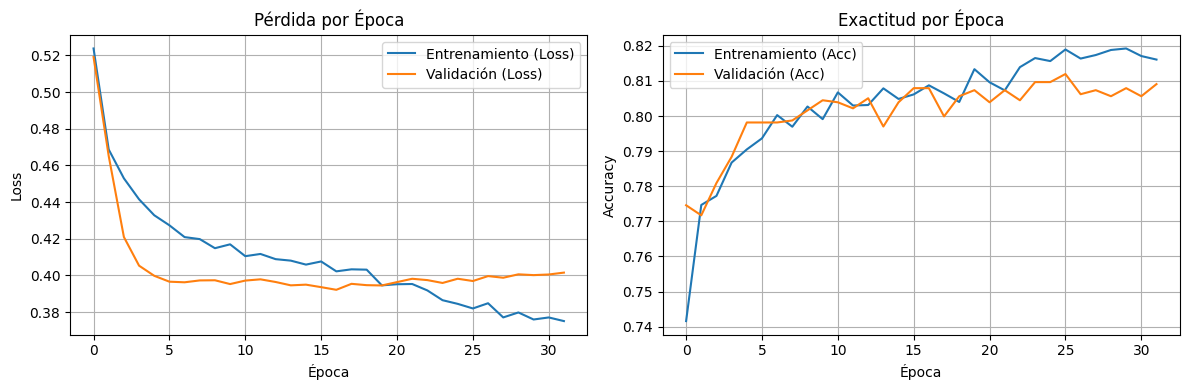

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
🔥 Exactitud Final en Validación (Accuracy): 0.8079

Reporte de Clasificación:
                 precision    recall  f1-score   support

No Transportado       0.80      0.81      0.81       863
    Transported       0.81      0.80      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



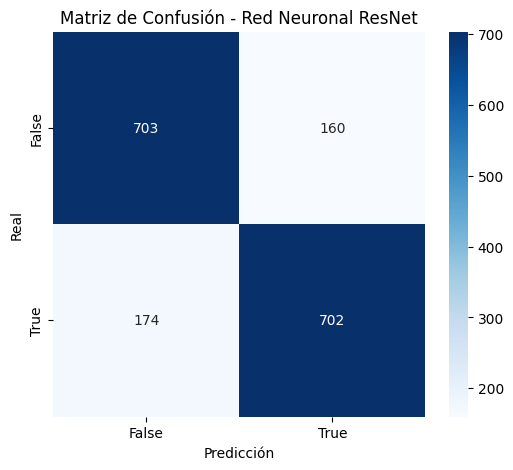

In [7]:
# 1. Graficar Curvas de Aprendizaje (Learning Curves)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento (Loss)')
plt.plot(history.history['val_loss'], label='Validación (Loss)')
plt.title('Pérdida por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento (Acc)')
plt.plot(history.history['val_accuracy'], label='Validación (Acc)')
plt.title('Exactitud por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('learning_curves_resnet.png', dpi=300)
plt.show()

# 2. Generar Predicciones sobre el conjunto de Validación
val_preds_prob = model.predict(X_val_pre)
val_preds = (val_preds_prob > 0.5).astype(int)

# 3. Mostrar Métricas de Clasificación
acc = accuracy_score(y_val, val_preds)
print(f"🔥 Exactitud Final en Validación (Accuracy): {acc:.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_val, val_preds, target_names=['No Transportado', 'Transported']))

# 4. Matriz de Confusión
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.title('Matriz de Confusión - Red Neuronal ResNet')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.savefig('confusion_matrix_resnet.png', dpi=300)
plt.show()

Celda 8: Generación del Archivo de Entrega Oficial para Kaggle (submission_7.csv)

In [8]:
# Hacer predicciones sobre el conjunto de prueba
test_preds_prob = model.predict(X_test_pre)
test_preds_boolean = (test_preds_prob > 0.5).flatten()

# Crear DataFrame con el formato exacto requerido por Kaggle
submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': test_preds_boolean
})

# Exportar submission_6.csv en la raíz del proyecto final
submission_df.to_csv('submission_6.csv', index=False)

print("✅ ¡Archivo 'submission_7.csv' guardado con éxito en la raíz del proyecto!")
print("\nDistribución de clases de la predicción final de test:")
print(submission_df['Transported'].value_counts())

134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
✅ ¡Archivo 'submission_7.csv' guardado con éxito en la raíz del proyecto!

Distribución de clases de la predicción final de test:
Transported
True     2179
False    2098
Name: count, dtype: int64
